<a href="https://www.kaggle.com/code/taraskin5201/hw2-3-dataset?scriptVersionId=294080537" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [6]:
import os

Ознайомитись з даними та структурою даних

In [7]:
data_dir = '/kaggle/input/fruit-recognition/train/train'

# Перевіряємо класи
classes = os.listdir(data_dir)
print("Класи:", classes)

# Кількість зображень у кожному класі
for cls in classes:
    cls_path = os.path.join(data_dir, cls)
    num_images = len(os.listdir(cls_path))
    print(f"{cls}: {num_images} зображень")

Класи: ['Orange', 'Tomato', 'Passion Fruit', 'Cucumber Ripe', 'Cactus fruit', 'Pomegranate', 'Plum', 'Pineapple', 'Papaya', 'Potato Red', 'Kiwi', 'Limes', 'Apple Braeburn', 'Pear', 'Onion White', 'Strawberry', 'Grape Blue', 'Blueberry', 'Apple Granny Smith', 'Apricot', 'Pepper Red', 'Clementine', 'Lemon', 'Avocado', 'Raspberry', 'Cantaloupe', 'Peach', 'Corn', 'Banana', 'Cherry', 'Pepper Green', 'Watermelon', 'Mango']
Orange: 479 зображень
Tomato: 738 зображень
Passion Fruit: 490 зображень
Cucumber Ripe: 392 зображень
Cactus fruit: 490 зображень
Pomegranate: 492 зображень
Plum: 447 зображень
Pineapple: 490 зображень
Papaya: 492 зображень
Potato Red: 450 зображень
Kiwi: 466 зображень
Limes: 490 зображень
Apple Braeburn: 492 зображень
Pear: 696 зображень
Onion White: 438 зображень
Strawberry: 492 зображень
Grape Blue: 984 зображень
Blueberry: 462 зображень
Apple Granny Smith: 492 зображень
Apricot: 492 зображень
Pepper Red: 666 зображень
Clementine: 490 зображень
Lemon: 492 зображень
Avoc

Створіть доповнення(transform) для тренувальних та тестових даних.

In [12]:
from torchvision import transforms

# Трансформації для тренувальних даних 
train_transform = transforms.Compose([
    transforms.Resize((128, 128)),  # змінюємо розмір
    transforms.ToTensor()           # перетворюємо у тензор
])

# Трансформації для тестових даних
test_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])


Створіть train_dataset та test_dataset за допомогою ImageFolder(папка train)

In [15]:
import torch
from torch.utils.data import random_split
from torchvision import datasets

In [16]:
data_dir = '/kaggle/input/fruit-recognition/train/train'

# Створюємо загальний dataset
dataset = datasets.ImageFolder(root=data_dir, transform=transform)

# Перевіримо класи
print("Класи:", dataset.classes)
print("Загальна кількість зображень:", len(dataset))


Класи: ['Apple Braeburn', 'Apple Granny Smith', 'Apricot', 'Avocado', 'Banana', 'Blueberry', 'Cactus fruit', 'Cantaloupe', 'Cherry', 'Clementine', 'Corn', 'Cucumber Ripe', 'Grape Blue', 'Kiwi', 'Lemon', 'Limes', 'Mango', 'Onion White', 'Orange', 'Papaya', 'Passion Fruit', 'Peach', 'Pear', 'Pepper Green', 'Pepper Red', 'Pineapple', 'Plum', 'Pomegranate', 'Potato Red', 'Raspberry', 'Strawberry', 'Tomato', 'Watermelon']
Загальна кількість зображень: 16854


In [17]:
# Визначаємо розміри
total_size = len(dataset)
train_size = int(0.8 * total_size)  # 80% для тренування
test_size = total_size - train_size # 20% для тесту

# Розділяємо dataset
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

print(f"Train size: {len(train_dataset)}, Test size: {len(test_dataset)}")


Train size: 13483, Test size: 3371


Переконайтесь що у вас привильні назви класів

In [18]:
print("Назви класів у train_dataset:", dataset.classes)
print("Назви класів у test_dataset:", dataset.classes)


Назви класів у train_dataset: ['Apple Braeburn', 'Apple Granny Smith', 'Apricot', 'Avocado', 'Banana', 'Blueberry', 'Cactus fruit', 'Cantaloupe', 'Cherry', 'Clementine', 'Corn', 'Cucumber Ripe', 'Grape Blue', 'Kiwi', 'Lemon', 'Limes', 'Mango', 'Onion White', 'Orange', 'Papaya', 'Passion Fruit', 'Peach', 'Pear', 'Pepper Green', 'Pepper Red', 'Pineapple', 'Plum', 'Pomegranate', 'Potato Red', 'Raspberry', 'Strawberry', 'Tomato', 'Watermelon']
Назви класів у test_dataset: ['Apple Braeburn', 'Apple Granny Smith', 'Apricot', 'Avocado', 'Banana', 'Blueberry', 'Cactus fruit', 'Cantaloupe', 'Cherry', 'Clementine', 'Corn', 'Cucumber Ripe', 'Grape Blue', 'Kiwi', 'Lemon', 'Limes', 'Mango', 'Onion White', 'Orange', 'Papaya', 'Passion Fruit', 'Peach', 'Pear', 'Pepper Green', 'Pepper Red', 'Pineapple', 'Plum', 'Pomegranate', 'Potato Red', 'Raspberry', 'Strawberry', 'Tomato', 'Watermelon']


Створіть DataLoader для тренувальних та тестових даних

In [19]:
from torch.utils.data import DataLoader


In [20]:
# Параметри
batch_size = 32  

# DataLoader для тренувальних даних
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# DataLoader для тестових даних
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


In [22]:
import matplotlib.pyplot as plt
import numpy as np

def imshow(img, title):
    npimg = img.numpy()  
    plt.imshow(np.transpose(npimg, (1, 2, 0)))  # Беремо перший батч з train_loader
dataiter = iter(train_loader)
images, labels = next(dataiter)

# Відображаємо перші 4 зображення
for i in range(4):
    imshow(images[i], title=dataset.classes[labels[i]])

    plt.title(title)
    plt.axis('off')
    plt.show()


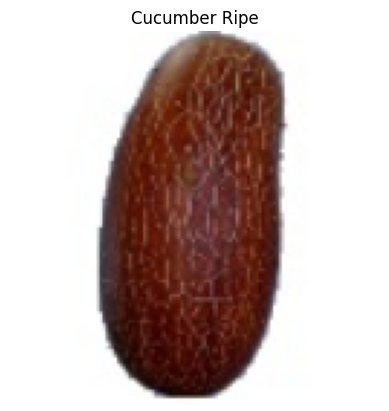

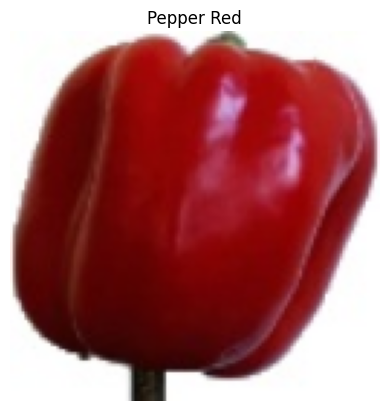

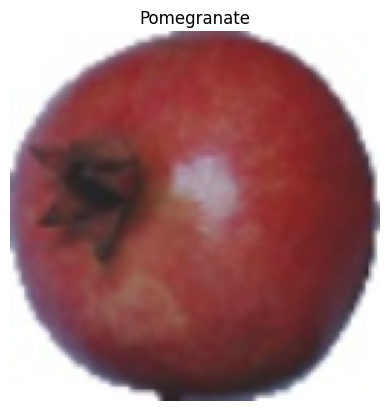

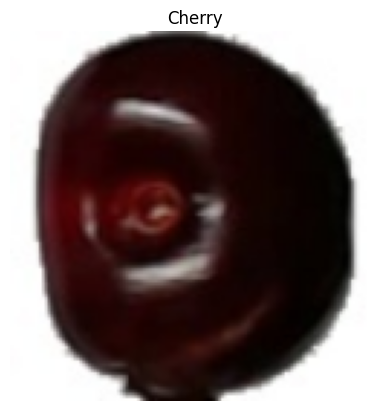

In [23]:
dataiter = iter(train_loader)
images, labels = next(dataiter)

# Відображаємо перші 4 зображення
for i in range(4):
    imshow(images[i], title=dataset.classes[labels[i]])


На основі train_dataset та test_dataset з попереднього завдання створити train_loader та test_loader

In [24]:

batch_size = 32

# DataLoader для тренувальних даних
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# DataLoader для тестових даних
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Перевіримо кількість батчів
print(f"Кількість батчів у train_loader: {len(train_loader)}")
print(f"Кількість батчів у test_loader: {len(test_loader)}")


Кількість батчів у train_loader: 422
Кількість батчів у test_loader: 106


Створити нейромережу:

використайте 3-5 шари

перший шар Flatten

кількість нейронів у шарах має не збільшуватись

використайте функції активації RELU або LeakyRELU

In [28]:
import torch.nn as nn

In [29]:
model = nn.Sequential(
    nn.Flatten(),                
    nn.Linear(128*128*3, 1024), 
    nn.ReLU(),
    nn.Linear(1024, 512),       
    nn.ReLU(),
    nn.Linear(512, 256),        
    nn.ReLU(),
    nn.Linear(256, 33)          
)
